In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/email.csv')

In [ ]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.shape

(5573, 2)

## 1. Data Cleaning

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [ ]:
df['Category'] = encoder.fit_transform(df['Category'])

In [ ]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Category'].value_counts()

,count
Category,
0,4825
1,747
2,1


In [ ]:
df = df.drop(df[df['Category'] == 2].index)

In [ ]:
# Check Missing Values

df.isnull().sum()

,0
Category,0
Message,0


In [ ]:
# Check Duplicate Values
df.duplicated().sum()


np.int64(415)

## 2. EDA

<Axes: xlabel='Category', ylabel='count'>

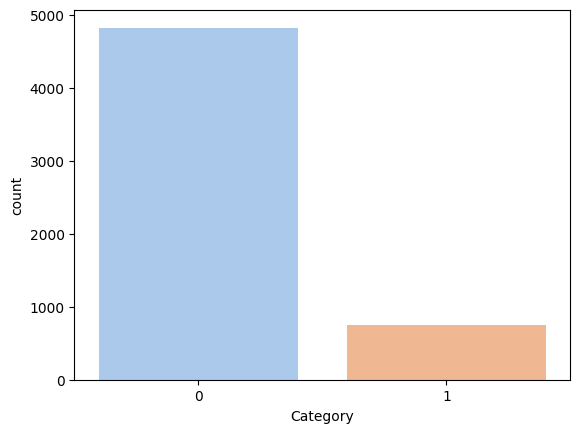

In [ ]:
sns.countplot(
    data = df,
    x = 'Category',
    palette = 'pastel'
)

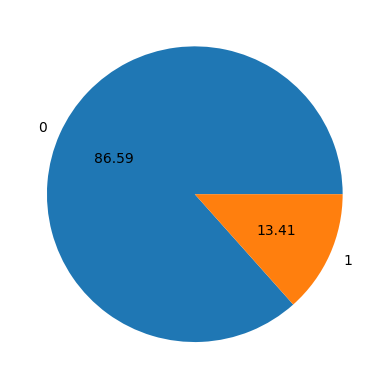


 Data is imbalcaned


In [ ]:
plt.pie(
    df.Category.value_counts(),
    labels=df.Category.value_counts().index,
    autopct="%.2f"
    )
plt.show()

print('\n Data is imbalcaned')

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Number of charecter in one row
df['Num_charecter'] = df['Message'].apply(len)

In [ ]:
# Number of word

df['Num_word']= df['Message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df['Num_sentance'] = df['Message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,Category,Message,Num_charecter,Num_word,Num_sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[['Num_charecter','Num_word','Num_sentance']].describe()

,Num_charecter,Num_word,Num_sentance
count,5572.000000,5572.000000,5572.000000
mean,80.368988,18.826992,2.004666
std,59.926946,13.853616,1.539516
min,2.000000,1.000000,1.000000
25%,35.750000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,122.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['Category'] == 0][['Num_charecter','Num_word','Num_sentance']].describe()

,Num_charecter,Num_word,Num_sentance
count,4825.000000,4825.000000,4825.000000
mean,71.448290,17.425699,1.846010
std,58.434864,14.118631,1.475377
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,93.000000,23.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='Num_charecter', ylabel='Count'>

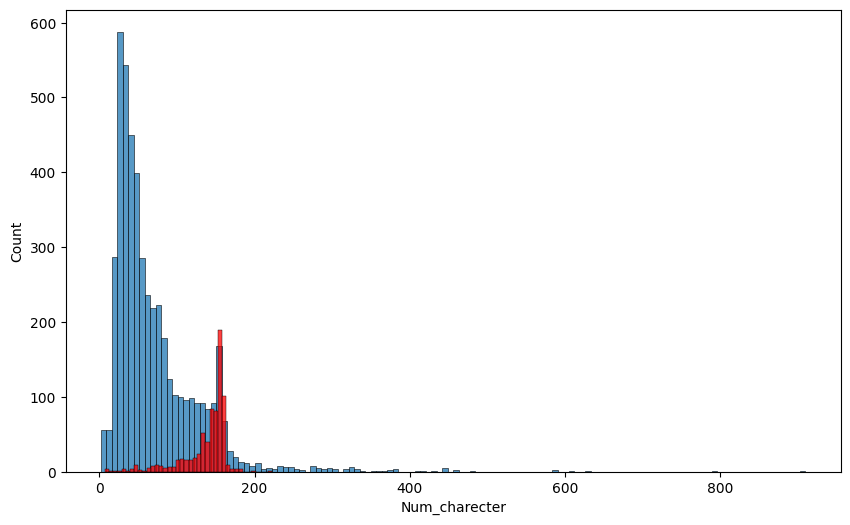

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['Category'] == 0]['Num_charecter'])
sns.histplot(df[df['Category'] == 1]['Num_charecter'],color = 'red')

<Axes: xlabel='Num_word', ylabel='Count'>

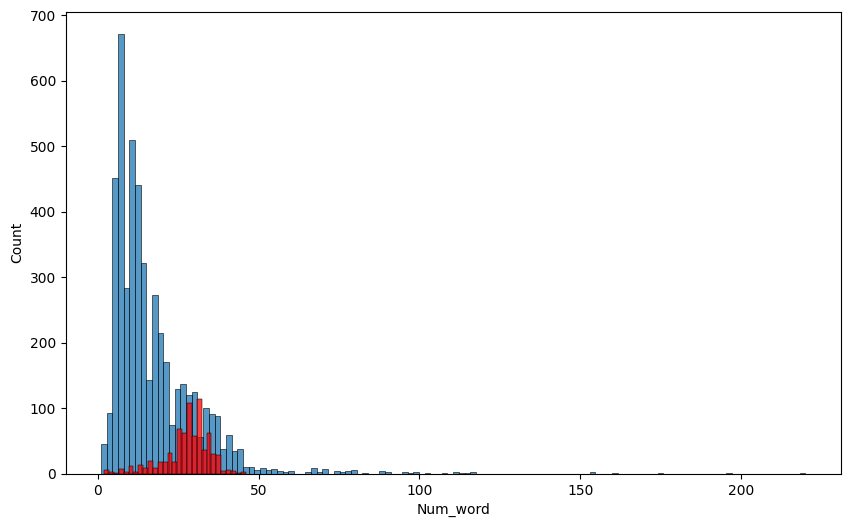

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(df[df['Category'] == 0]['Num_word'])
sns.histplot(df[df['Category'] == 1]['Num_word'],color = 'red')

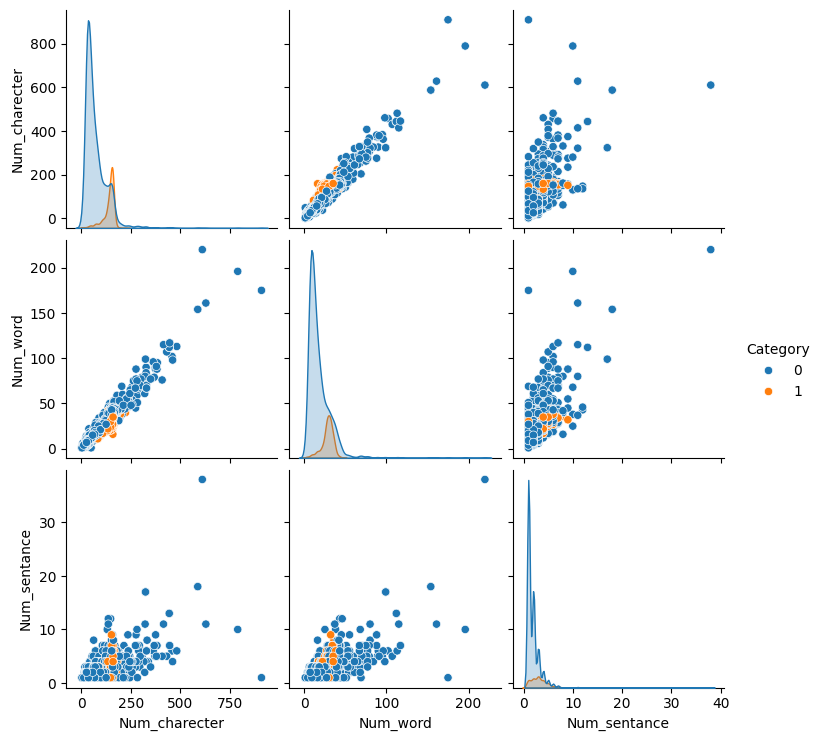

In [ ]:
sns.pairplot(df,hue = 'Category')

<Axes: >

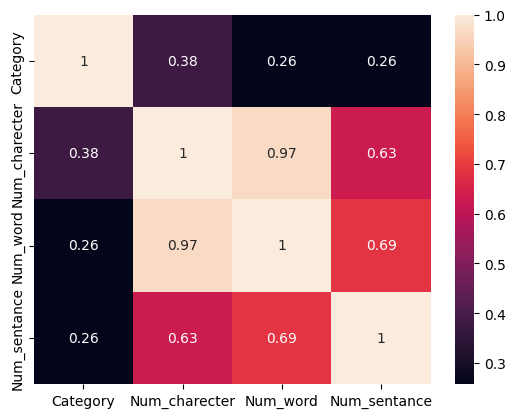

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot = True)

## 3. Data preprocessing


*   Lower Case
*   Tokenization
*   Removing Special Charecter
*   Removing stop wards and punctuation
*   Stemming



In [ ]:
import string
from nltk.corpus import stopwords


string.punctuation
stopwords.words('english')


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
def transformed_data(Message):
    Message = Message.lower()
    Message = nltk.word_tokenize(Message)
    ps = nltk.PorterStemmer()
    stem = lambda word: ps.stem(word)
    y = []
    for i in Message:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    return ' '.join(y)

In [ ]:
transformed_data(df['Message'][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [ ]:
df['transformed_data'] = df['Message'].apply(transformed_data)

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width = 500,height = 500,min_font_size = 10,background_color = 'white')

In [ ]:
wc_spam = wc.generate(df[df['Category'] == 1]['transformed_data'].str.cat(sep = ' '))

In [ ]:
wc_ham = wc.generate(df[df['Category'] == 0]['transformed_data'].str.cat(sep = ' '))

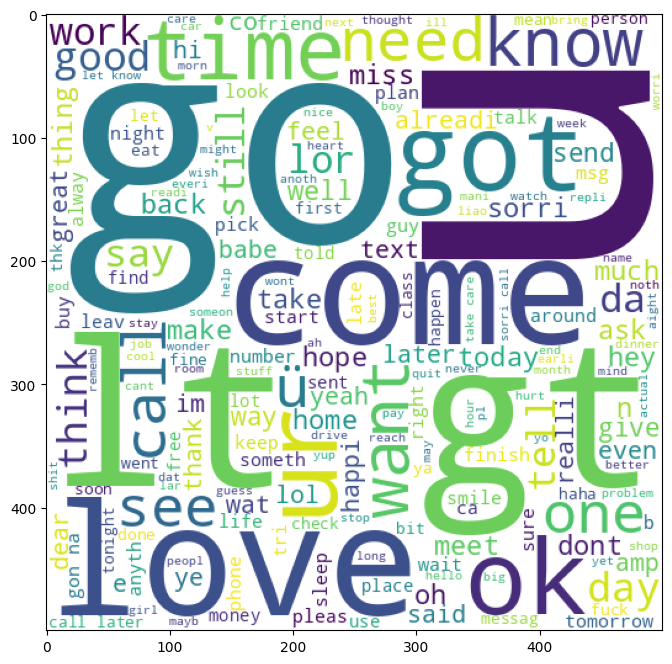

In [ ]:
plt.figure(figsize = (15,8))
plt.imshow(wc_spam)
plt.show()



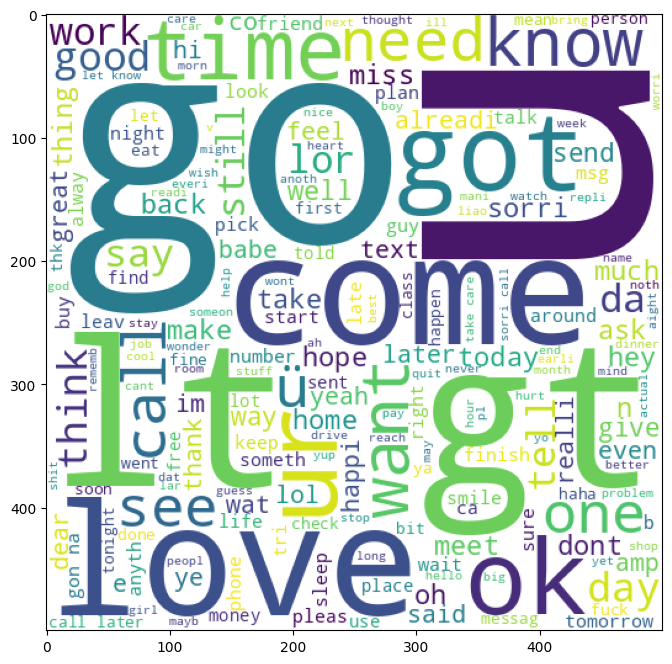

In [ ]:
plt.figure(figsize = (15,8))
plt.imshow(wc_ham)
plt.show()

In [ ]:
spam_corpus = []

for sentence in df[df['Category'] == 1]['transformed_data'].tolist():
    for word in sentence.split():
        spam_corpus.append(word)


In [ ]:
len(spam_corpus)

11506

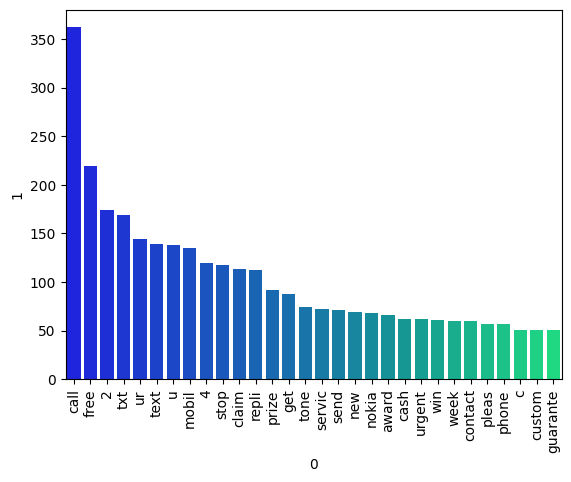

In [ ]:
from collections import Counter

count_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=count_df[0], y=count_df[1],palette='winter')
plt.xticks(rotation=90)
plt.show()

In [ ]:
ham_corpus = []

for sentence in df[df['Category'] == 0]['transformed_data'].tolist():
    for word in sentence.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

38819

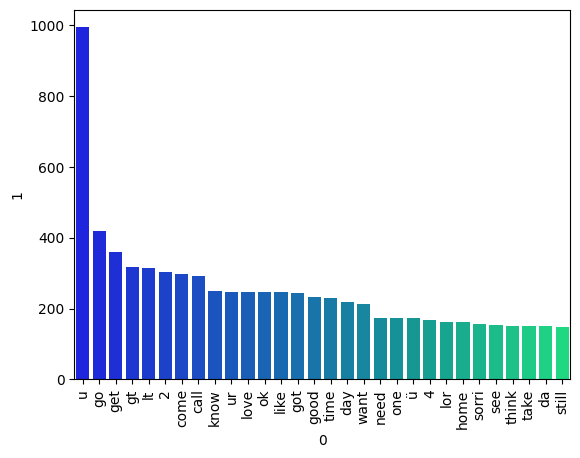

In [ ]:
from collections import Counter

count_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=count_df[0], y=count_df[1],palette='winter')
plt.xticks(rotation=90)
plt.show()

# 4. Model Buliding

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

cv = CountVectorizer()
tf = TfidfVectorizer(max_features = 3000)

In [ ]:
x = tf.fit_transform(df['transformed_data']).toarray()

In [ ]:
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
x.shape

(5572, 3000)

In [ ]:
y = df['Category'].values

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [ ]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.852017937219731
[[818 139]
 [ 26 132]]
0.4870848708487085


In [ ]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9704035874439462
[[957   0]
 [ 33 125]]
1.0


In [ ]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9721973094170404
[[955   2]
 [ 29 129]]
0.9847328244274809


In [ ]:
#tfidf --> MNB

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
lg = LogisticRegression()
svc = SVC(kernel = 'sigmoid',gamma = 1.0)
mnb = MultinomialNB()
dt = DecisionTreeClassifier(max_depth = 10)
rf = RandomForestClassifier(n_estimators = 100,random_state = 2)
knn = KNeighborsClassifier(n_neighbors = 10)
ada = AdaBoostClassifier(n_estimators = 100)
bc = BaggingClassifier(n_estimators = 100)
etc = ExtraTreesClassifier(n_estimators = 100)
gbdt = GradientBoostingClassifier(n_estimators = 100)
xgb = XGBClassifier(n_estimators = 100,verbosity = 0)

In [ ]:
models = {
    'Logistic': lg,
    'SVC': svc,
    'MultinomialNB': mnb,
    'Decision Tree': dt,
    'KNearestN': knn,
    'RandomForest': rf,
    'Ada': ada,
    'BaggingClassifier': bc,
    'ExtraTree': etc,
    'Gredient': gbdt,
    'XGBoost': xgb
}

In [ ]:
def train_classifier(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [ ]:
train_classifier(lg,x_train,y_train,x_test,y_test)

(0.9551569506726457, 0.990909090909091)

In [ ]:
accuracy_scores = []
precision_scores = []

for name, model in models.items():

    current_accuracy, current_precision = train_classifier(
        model,
        x_train,
        y_train,
        x_test,
        y_test
    )

    print("For :", name)
    print("Accuracy :", current_accuracy)
    print("Precision :", current_precision)
    print()

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For : Logistic
Accuracy : 0.9551569506726457
Precision : 0.990909090909091

For : SVC
Accuracy : 0.9695067264573991
Precision : 0.9558823529411765

For : MultinomialNB
Accuracy : 0.9704035874439462
Precision : 1.0

For : Decision Tree
Accuracy : 0.9461883408071748
Precision : 0.8602941176470589

For : KNearestN
Accuracy : 0.8878923766816144
Precision : 1.0

For : RandomForest
Accuracy : 0.9748878923766816
Precision : 0.9924242424242424

For : Ada
Accuracy : 0.9264573991031391
Precision : 0.8958333333333334

For : BaggingClassifier
Accuracy : 0.9623318385650225
Precision : 0.881578947368421

For : ExtraTree
Accuracy : 0.9748878923766816
Precision : 0.9850746268656716

For : Gredient
Accuracy : 0.9596412556053812
Precision : 0.9669421487603306

For : XGBoost
Accuracy : 0.967713004484305
Precision : 0.9485294117647058



In [ ]:
performance_df = pd.DataFrame({
    'Algorithm': list(models.keys()),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values(by='Precision', ascending=False).reset_index(drop=True)

In [ ]:
performance_df1 = pd.melt(
    performance_df,
    id_vars='Algorithm',
    value_vars=['Accuracy', 'Precision']
)

performance_df1

,Algorithm,variable,value
0,MultinomialNB,Accuracy,0.970404
1,KNearestN,Accuracy,0.887892
2,RandomForest,Accuracy,0.974888
3,Logistic,Accuracy,0.955157
4,ExtraTree,Accuracy,0.974888
5,Gredient,Accuracy,0.959641
6,SVC,Accuracy,0.969507
7,XGBoost,Accuracy,0.967713
8,Ada,Accuracy,0.926457
9,BaggingClassifier,Accuracy,0.962332


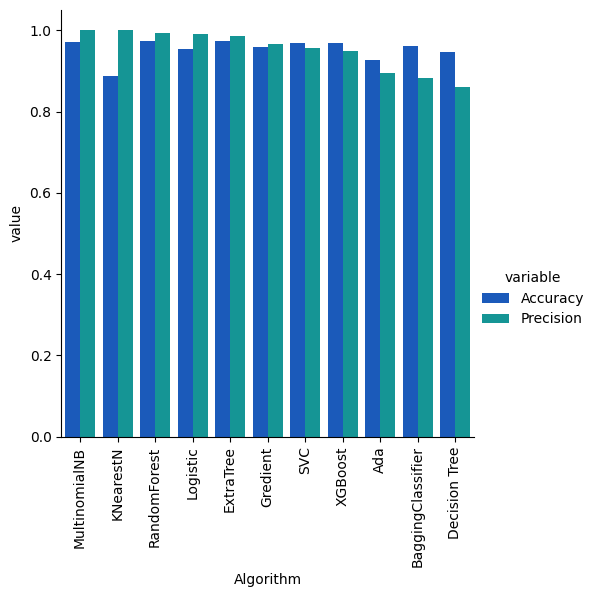

In [ ]:
sns.catplot(
    data=performance_df1,
    x='Algorithm',
    y='value',
    hue='variable',
    kind='bar',
    height = 5,
    palette='winter'
)
plt.xticks(rotation=90)
plt.show()

# 5. Evaluation

In [ ]:
temp_df = pd.DataFrame({
    'Algorithm':models.keys(),
    'Accuracy_max_ft_3000':accuracy_scores,
    'Precision_max_ft_3000':precision_scores
}).sort_values('Precision_max_ft_3000',ascending=False)

In [ ]:
temp_df = pd.DataFrame({
    'Algorithm':models.keys(),
    'Accuracy_scaling':accuracy_scores,
    'Precision_scaling':precision_scores
}).sort_values('Precision_scaling',ascending=False)

In [ ]:
temp_df

,Algorithm,Accuracy_scaling,Precision_scaling
2,MultinomialNB,0.970404,1.000000
4,KNearestN,0.887892,1.000000
5,RandomForest,0.974888,0.992424
0,Logistic,0.955157,0.990909
8,ExtraTree,0.974888,0.985075
9,Gredient,0.959641,0.966942
1,SVC,0.969507,0.955882
10,XGBoost,0.967713,0.948529
6,Ada,0.926457,0.895833
7,BaggingClassifier,0.962332,0.881579


In [ ]:
# Voting Classifier

mnb = MultinomialNB()
rf = RandomForestClassifier(n_estimators = 100,random_state = 3)
etc = ExtraTreesClassifier(n_estimators = 100)

In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('MultinomialNB', mnb),
        ('RandomForest', rf),
        ('ExtraTree', etc)
    ],
    voting='soft'
)

In [ ]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('MultinomialNB', MultinomialNB()),
                             ('RandomForest',
                              RandomForestClassifier(random_state=3)),
                             ('ExtraTree', ExtraTreesClassifier())],
                 voting='soft')

In [ ]:
y_pred = voting.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9730941704035875
1.0


In [ ]:
# Applying Stacking

estimators = [
    ('MultinomialNB', mnb),
    ('RandomForest', rf),
    ('ExtraTree', etc)
]
final_estimator = RandomForestClassifier(n_estimators = 100,random_state = 2)

In [ ]:
from sklearn.ensemble import StackingClassifier

model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=3
)

In [ ]:
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9802690582959641
0.9857142857142858


In [ ]:
model = RandomForestClassifier(n_estimators = 100,random_state = 2)

model.fit(x_train,y_train)


(0.9766816143497757, 1.0)

In [ ]:
import pickle

pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(model,open('model.pkl','wb'))